In [ ]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [51]:
df = pd.read_csv("/content/Clean_Dataset.csv")

le = LabelEncoder()
scaler = StandardScaler()

for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col])
  else:
    df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))



for col in df:
  if df[col].isnull().sum() > 0 and df[col].dtype != "object":
    df.fillna(df[col].mean(), inplace=True)


y = df['price']
x = df.drop('price', axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (240122, 11)
x_test : (60031, 11)
y_train : (240122,)
y_test : (60031,)



In [52]:
print(df)

        Unnamed: 0  airline  flight  source_city  departure_time  stops  \
0        -1.732045        4    1408            2               2      2   
1        -1.732033        4    1387            2               1      2   
2        -1.732022        0    1213            2               1      2   
3        -1.732010        5    1559            2               4      2   
4        -1.731999        5    1549            2               4      2   
...            ...      ...     ...          ...             ...    ...   
300148    1.731999        5    1477            1               4      0   
300149    1.732010        5    1481            1               0      0   
300150    1.732022        5    1486            1               1      0   
300151    1.732033        5    1483            1               1      0   
300152    1.732045        5    1477            1               4      0   

        arrival_time  destination_city  class  duration  days_left     price  
0                  5

In [53]:
print(y_train)

148417   -0.324511
36879    -0.482412
274531    1.546117
166397   -0.571099
272722    1.524925
            ...   
119879    0.087204
259178    1.030515
131932   -0.695561
146867   -0.674766
121958   -0.641062
Name: price, Length: 240122, dtype: float64


In [55]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    explained_variance_score  )

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='reg:squarederror',
    tree_method='auto')

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

# accuracy_scores = accuracy_score(y_test, y_pred)
# precision_scores = precision_score(y_test, y_pred)
# recall_scores = recall_score(y_test, y_pred)
# f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# print(f"""
# Accuracy Score : {accuracy_scores}
# Precision Score : {precision_scores}
# Recall Score : {recall_scores}
# F1 Score : {f1_scores} """)

r2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2_score}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.9795800722901492
Mean Absolute Error: 0.07999322402606829
Mean Squared Error: 0.020431634054848657


In [33]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
# disp.plot(cmap=plt.cm.Blues)
# plt.xlabel('Predicted student data')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [36]:
# print(classification_report(y_test, y_pred))

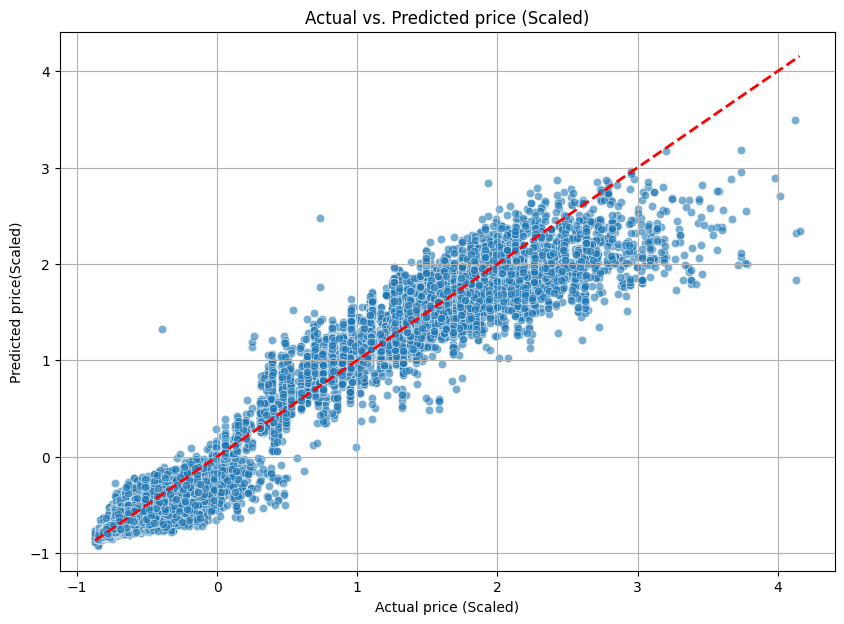

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted price (Scaled)')
plt.xlabel('Actual price (Scaled)')
plt.ylabel('Predicted price(Scaled)')
plt.grid(True)
plt.show()

In [57]:
import joblib
if joblib.dump(xgb_model, 'flight price prediction.pkl'):
  print("model saved")

model saved
